# TrustSight Analytics analysis and visualization walkthrough
This notebook shows how the output artifacts are used to inspect the phishing attribution path, suspicious login behavior, and customer risk segmentation.

In [10]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'data' / 'raw').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'data' / 'raw').exists():
    raise RuntimeError('Cannot locate project root with data/raw')

sys.path.insert(0, str(ROOT))

feature_path = ROOT / 'output' / 'features' / 'customer_features.csv'
anomaly_path = ROOT / 'output' / 'anomalies' / 'login_anomalies.csv'
risk_path = ROOT / 'output' / 'scores' / 'customer_risk_scores.csv'

features = pd.read_csv(feature_path)
anomalies = pd.read_csv(anomaly_path) if anomaly_path.exists() else pd.DataFrame()
scores = pd.read_csv(risk_path) if risk_path.exists() else pd.DataFrame()

print('Features', features.shape)
print('Anomalies', anomalies.shape)
print('Scores', scores.shape)

Features (1000, 20)
Anomalies (4181, 13)
Scores (1000, 23)


## Risk bucket breakdown
Explore how risk score buckets align with phishing exposure and suspicious login signal.

In [11]:
if 'risk_bucket' not in features.columns or 'risk_score' not in features.columns:
    if 'customer_id' in scores.columns:
        merge_cols = ['customer_id']
        if 'risk_bucket' in scores.columns:
            merge_cols.append('risk_bucket')
        if 'risk_score' in scores.columns:
            merge_cols.append('risk_score')
        features = features.merge(
            scores[merge_cols],
            on='customer_id',
            how='left',
        )
    if 'risk_bucket' not in features.columns:
        features['risk_bucket'] = 'unknown'
    if 'risk_score' not in features.columns:
        features['risk_score'] = None

summary = features.groupby('risk_bucket').agg(
    customers=('customer_id', 'nunique'),
    phishing_messages=('phish_messages', 'sum'),
    suspicious_logins=('suspicious_login_events', 'sum'),
    suspicious_logins_after_phish=('suspicious_logins_after_phish', 'sum'),
    fraud_orders_after_phish=('fraud_orders_after_phish', 'sum')
).reset_index()
summary

,risk_bucket,customers,phishing_messages,suspicious_logins,suspicious_logins_after_phish,fraud_orders_after_phish
0,critical,60,1312,60.0,60.0,60.0
1,high,137,2959,85.0,85.0,1.0
2,low,157,2092,0.0,0.0,0.0
3,medium,646,12954,0.0,0.0,0.0


## Top customers by attribution signal
Identify customers with the strongest phishing-to-fraud path in the synthetic dataset.

In [12]:
top_path = features.sort_values(
    ['fraud_orders_after_phish', 'suspicious_logins_after_phish', 'phish_messages'],
    ascending=[False, False, False]
).head(10)
top_path[['customer_id', 'phish_messages', 'suspicious_login_events', 'suspicious_logins_after_phish', 'fraud_orders_after_phish', 'risk_score', 'risk_bucket']]

,customer_id,phish_messages,suspicious_login_events,suspicious_logins_after_phish,fraud_orders_after_phish,risk_score,risk_bucket
890,C100890,24,1.0,1.0,2.0,100.000000,critical
306,C100306,20,1.0,1.0,2.0,94.974874,critical
917,C100917,19,1.0,1.0,2.0,94.723618,critical
203,C100203,18,1.0,1.0,2.0,92.462312,critical
654,C100654,18,1.0,1.0,2.0,92.964824,critical
739,C100739,18,1.0,1.0,2.0,92.964824,critical
277,C100277,17,1.0,1.0,2.0,91.457286,critical
16,C100016,15,1.0,1.0,2.0,98.994975,critical
571,C100571,15,1.0,1.0,2.0,88.944724,critical
24,C100024,28,1.0,1.0,1.0,87.437186,critical


## Visualization: phishing attribution by risk bucket
Plot the contribution of suspicious logins and fraud orders after phishing exposure.

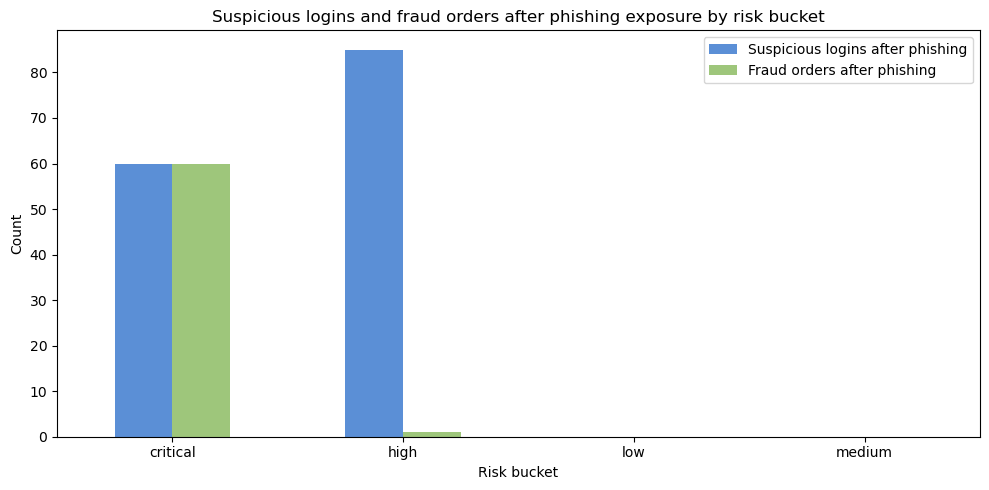

In [13]:
plot_data = summary.set_index('risk_bucket')[['suspicious_logins_after_phish', 'fraud_orders_after_phish']]
ax = plot_data.plot(kind='bar', figsize=(10, 5), rot=0, color=['#5b8fd6', '#9ec67b'])
ax.set_title('Suspicious logins and fraud orders after phishing exposure by risk bucket')
ax.set_xlabel('Risk bucket')
ax.set_ylabel('Count')
ax.legend(['Suspicious logins after phishing', 'Fraud orders after phishing'])
plt.tight_layout()
plt.show()

## Visualization: login anomaly signal
When anomaly detection is available, this plot highlights the frequency of flagged login events against the model output.

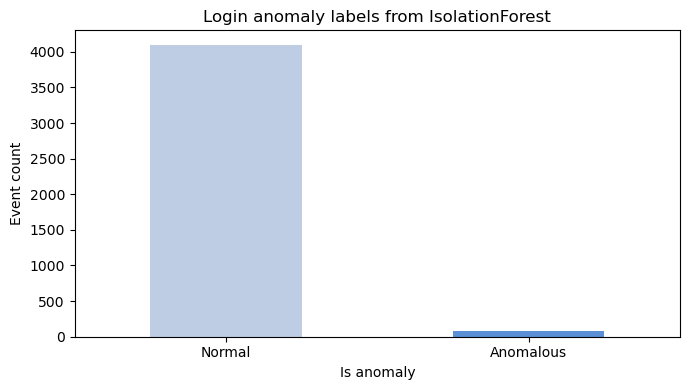

In [14]:
if not anomalies.empty:
    anomaly_counts = anomalies.groupby('is_anomaly').size().reindex([False, True], fill_value=0)
    fig, ax = plt.subplots(figsize=(7, 4))
    anomaly_counts.plot(kind='bar', ax=ax, color=['#becde4', '#5b8fd6'])
    ax.set_title('Login anomaly labels from IsolationForest')
    ax.set_xlabel('Is anomaly')
    ax.set_ylabel('Event count')
    ax.set_xticklabels(['Normal', 'Anomalous'], rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No anomaly output found. Run python/python/anomaly_detection.py first.')